<a href="https://colab.research.google.com/github/arghachowdhury2006-gif/heart-disease-data-preprocessing/blob/main/Project_Heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("raw_heart_dataset.csv")
print(df.head())
print("Shape:", df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  
Shape: (1888, 14)


In [24]:
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Shape after removing duplicates: (602, 14)


In [25]:
# Normalization Using Z-score logic
mean_bps = df["trestbps"].mean()
std_bps = df["trestbps"].std()
df["trestbps_z"] = (df["trestbps"] - mean_bps) / std_bps
print(df["trestbps_z"].head())

0    0.763150
1   -0.093544
2   -0.093544
3   -0.664673
4   -0.664673
Name: trestbps_z, dtype: float64


In [26]:
# Using Math module
df["age_sqrt"] = df["age"].apply(math.sqrt)
print(df["age_sqrt"].head())

0    7.937254
1    6.082763
2    6.403124
3    7.483315
4    7.549834
Name: age_sqrt, dtype: float64


In [27]:
# Using Random module
random.seed(42)
sample_ids = random.sample(list(df.index), 5)
print("Randomly sampled indices:", sample_ids)

Randomly sampled indices: [114, 25, 282, 251, 229]


In [28]:
# Calculate mean of cholesterol and heart rate using numpy arrays
stats_arr = np.array(df[["chol", "thalachh"]])
mean_stats = stats_arr.mean(axis=0)
print(f"Average Cholesterol: {mean_stats[0]:.2f}, Average Max Heart Rate: {mean_stats[1]:.2f}")

Average Cholesterol: 248.45, Average Max Heart Rate: 149.27


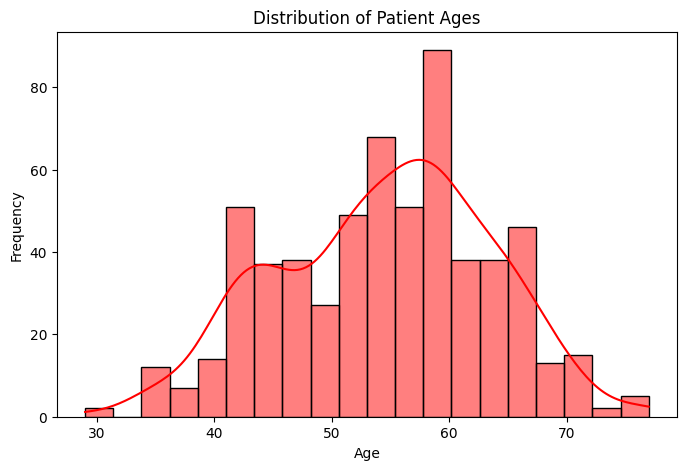

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='red')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

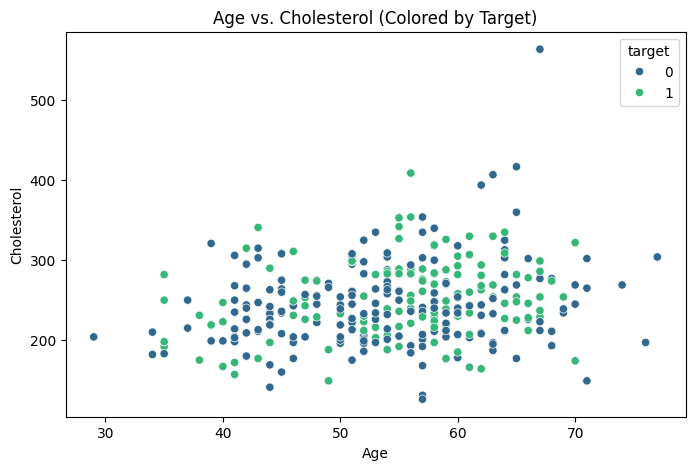

In [30]:
# Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='viridis')
plt.title('Age vs. Cholesterol (Colored by Target)')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

/tmp/ipykernel_6222/1479337190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


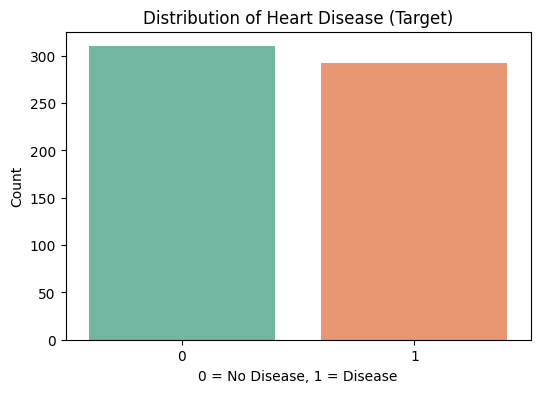

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribution of Heart Disease (Target)')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

In [32]:
# updated dataset
print(df[["age", "trestbps", "trestbps_z", "target"]].head())

   age  trestbps  trestbps_z  target
0   63       145    0.763150       1
1   37       130   -0.093544       1
2   41       130   -0.093544       1
3   56       120   -0.664673       1
4   57       120   -0.664673       1
